Vamos a empezar sacando el porcentaje de ISMs de cada transcrito y luego tendremos que colapsar

In [ ]:
import pandas as pd
import polars as pl
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score
from pathlib import Path
import joblib

mt = pd.read_csv("../megatabla_7.tsv", sep = "\t")
mt["RIN_TS"] = mt["RIN"].astype(str) + mt["TS"].astype(str)
rin_ts_combs = mt[["RIN_TS"]].drop_duplicates()
n_combs = mt.drop_duplicates(["associated_transcript", "RIN_TS"]).groupby("associated_transcript").size()
mt["n_combs"] = mt["associated_transcript"].map(n_combs)
n_combs_max = mt["n_combs"].max()
mt_filt = mt.copy()
total_counts = mt_filt.groupby(['associated_transcript', 'RIN_TS'])['counts'].sum().reset_index(name='total_transcript_counts')
ism_counts = mt_filt[mt_filt['structural_category'] == 'incomplete-splice_match'].groupby(['associated_transcript', 'RIN_TS'])['counts'].sum().reset_index(name='ism_counts')

ISMs = pd.merge(total_counts, ism_counts, on=['associated_transcript', 'RIN_TS'], how='left')
ISMs['ism_counts'] = ISMs['ism_counts'].fillna(0) # Si no hay ISMs, es 0
ISMs['porc_ISM'] = (ISMs['ism_counts'] / ISMs['total_transcript_counts']) * 100
cols_estaticas = ['associated_gene','associated_transcript', 'ref_length', 'ref_exons', 
                  'strand','counts_transcript','TS', 'RIN', 
                  'seqbatch', 'time','dip_test_TSS', 'dip_test_TSS_pval',
                  'exon_junction_density', 'porc_GC', 'CPM_transcript',
                  'length_CDS', 'porc_GC_CDS', 'length_3pUTR', 'porc_GC_3pUTR',
                  'length_5pUTR', 'porc_GC_5pUTR', 'RIN_TS', 'n_combs']
mt_estatico = mt_filt[cols_estaticas].drop_duplicates(subset=["associated_transcript","RIN_TS"])
ISMs = pd.merge(ISMs, mt_estatico, on=['associated_transcript','RIN_TS'], how='left')

cols_dinamicas = ['length','diff_to_gene_TSS','diff_to_gene_TTS','CV_diff_to_gene_TSS',
                  'CV_diff_to_gene_TTS','Cov_D1','Cov_D2', 'Cov_D3',
                  'Cov_D4', 'Cov_D5', 'Cov_D6', 'Cov_D7', 
                  'Cov_D8', 'Cov_D9','Cov_D10']
# Para cada columna de la que queremos sacar la media ponderada
for col in cols_dinamicas:
       mt_filt[f'{col}_ponderada'] = mt_filt[col]*mt_filt["counts"]
instrucciones = {f'{col}_ponderada' :'sum' for col in cols_dinamicas}
instrucciones["counts"] = 'sum'
dinamicas_grouped = mt_filt.groupby(["associated_transcript","RIN_TS"]).agg(instrucciones).reset_index()
for col in cols_dinamicas:
    dinamicas_grouped[f'avg_{col}'] = dinamicas_grouped[f'{col}_ponderada'] / dinamicas_grouped['counts']
cols_finales = ['associated_transcript', 'RIN_TS', 'counts'] + [f'avg_{col}' for col in cols_dinamicas]
df_dinamicas_limpio = dinamicas_grouped[cols_finales]
df_dinamicas_limpio.rename(columns={'counts': 'total_counts'}, inplace=True)
df_final = pd.merge(ISMs,df_dinamicas_limpio, on=["associated_transcript","RIN_TS"], how="left")
df_final['strand'] = df_final['strand'].map({'+': 1, '-': 0})
cols_drop = ["associated_transcript", "associated_gene", "RIN_TS","porc_ISM","ism_counts","seqbatch","time","n_combs","total_counts","TS"]


X_train = df_final[(df_final["RIN"] != 9.9) & (df_final["n_combs"] == n_combs_max)].drop(columns=cols_drop)
y_train = df_final[(df_final["RIN"] != 9.9) & (df_final["n_combs"] == n_combs_max)]["porc_ISM"]

# Test 1: Transcritos de RIN 9.9 que estaban en el set de entrenamiento
X_test_vistos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] == n_combs_max)].drop(columns=cols_drop)
y_test_vistos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] == n_combs_max)]["porc_ISM"]

# Test 2: Transcritos de RIN 9.9 NUEVOS (no estaban en todas las muestras)
X_test_nuevos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] < n_combs_max)].drop(columns=cols_drop)
y_test_nuevos = df_final[(df_final["RIN"] == 9.9) & (df_final["n_combs"] < n_combs_max)]["porc_ISM"]

C:\Users\Andres\AppData\Local\Temp\ipykernel_10740\1370361629.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dinamicas_limpio.rename(columns={'counts': 'total_counts'}, inplace=True)


In [66]:
import joblib

# Cargamos el modelo desde el archivo
mejor_modelo = joblib.load('mejor_modelo_ism.pkl')


--- TEST: TRANSCRITOS QUE YA ESTABAN EN EL TRAINING SET
MAE: 6.041869558653812
RMSE: 124.81480320572125
R²: 0.929136793021019

--- TEST: TRANSCRITOS QUE NO ESTABAN EN EL TRAINING SET
MAE: 14.53597761496392
RMSE: 586.980564087565
R²: 0.736094455789837


Text(0.5, 0.98, 'Model performance: Prediction vs Reality')

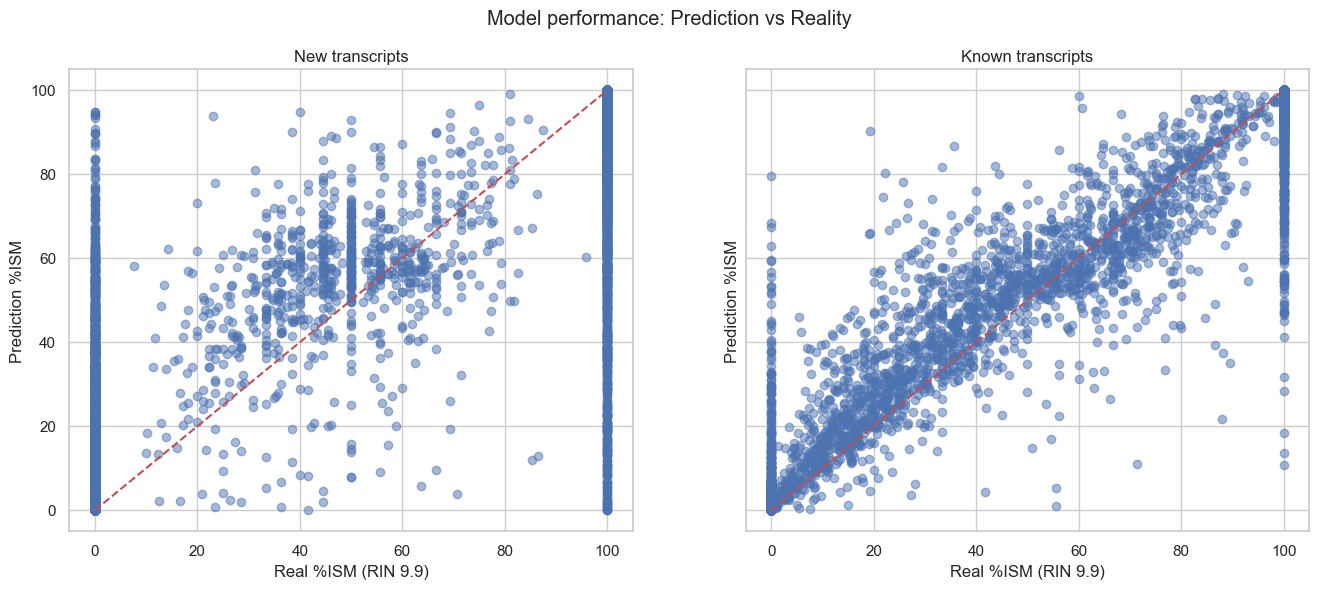

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

predicciones_vistos = mejor_modelo.predict(X_test_vistos)
print("\n--- TEST: TRANSCRITOS QUE YA ESTABAN EN EL TRAINING SET")
print("MAE:", mean_absolute_error(y_test_vistos, predicciones_vistos))
print("RMSE:", mean_squared_error(y_test_vistos, predicciones_vistos))
print("R²:", r2_score(y_test_vistos, predicciones_vistos))

predicciones_nuevos = mejor_modelo.predict(X_test_nuevos)
print("\n--- TEST: TRANSCRITOS QUE NO ESTABAN EN EL TRAINING SET")
print("MAE:", mean_absolute_error(y_test_nuevos, predicciones_nuevos))
print("RMSE:", mean_squared_error(y_test_nuevos, predicciones_nuevos))
print("R²:", r2_score(y_test_nuevos, predicciones_nuevos))

# Guardar el modelo entrenado
joblib.dump(mejor_modelo, 'mejor_modelo_ism.pkl')
# Guardar los datos finales (X_test, y_test, predicciones) en un CSV o parquet
# Unir las predicciones a los dataframes originales para guardarlos
df_resultados_vistos = X_test_vistos.copy()
df_resultados_vistos['porc_ISM_real'] = y_test_vistos
df_resultados_vistos['prediccion'] = predicciones_vistos
df_resultados_vistos.to_csv('resultados_modelo_vistos.csv', index=False)

df_resultados_nuevos = X_test_nuevos.copy()
df_resultados_nuevos['porc_ISM_real'] = y_test_nuevos
df_resultados_nuevos['prediccion'] = predicciones_nuevos
df_resultados_nuevos.to_csv('resultados_modelo_nuevos.csv', index=False)

import matplotlib.pyplot as plt
n=0
for ax, i in zip(axes,[(y_test_nuevos,predicciones_nuevos),(y_test_vistos,predicciones_vistos)]):
    ax.scatter(i[0], i[1], alpha=0.5)
    ax.plot([i[0].min(), i[0].max()], [i[0].min(), i[0].max()], 'r--')
    ax.set_xlabel("Real %ISM (RIN 9.9)")
    ax.set_ylabel("Prediction %ISM")
    ax.set_title("New transcripts" if n==0 else "Known transcripts")
    n+=1
fig.suptitle("Model performance: Prediction vs Reality")


--- FEATURE IMPORTANCES ---
                    Feature  Importance
18     avg_diff_to_gene_TSS    0.380213
2                 ref_exons    0.173626
20  avg_CV_diff_to_gene_TSS    0.125917
8     exon_junction_density    0.063099
11               length_CDS    0.033933
17               avg_length    0.029059
23               avg_Cov_D2    0.025498
6              dip_test_TSS    0.016090
15             length_5pUTR    0.014346
1                ref_length    0.013252
13             length_3pUTR    0.012394
7         dip_test_TSS_pval    0.012235
9                   porc_GC    0.010581
14            porc_GC_3pUTR    0.010170
22               avg_Cov_D1    0.008952
16            porc_GC_5pUTR    0.008806
24               avg_Cov_D3    0.007265
19     avg_diff_to_gene_TTS    0.007174
12              porc_GC_CDS    0.006355
5                       RIN    0.005592
31              avg_Cov_D10    0.005394
10           CPM_transcript    0.005234
25               avg_Cov_D4    0.003558
26          

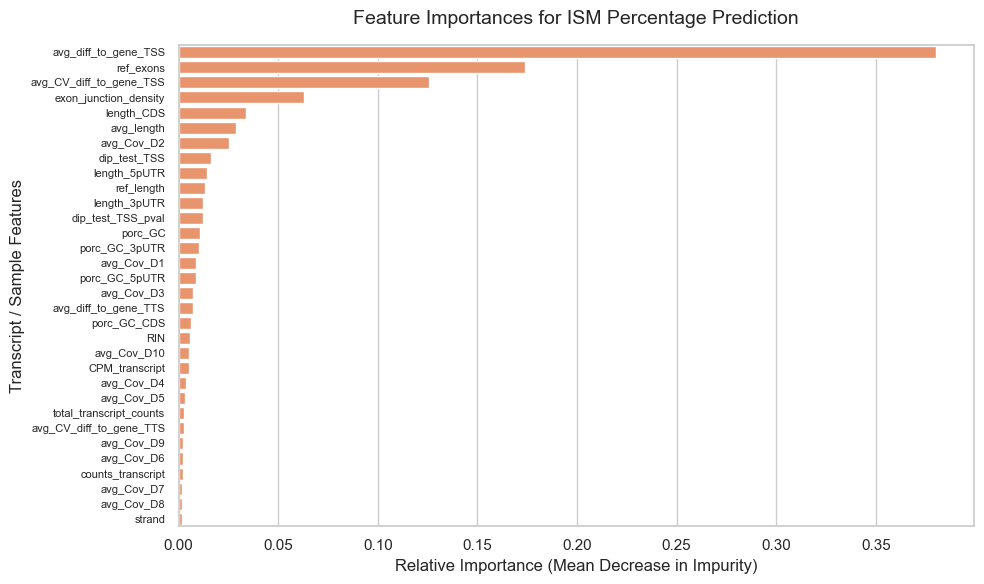

In [68]:
import seaborn as sns
importancias = mejor_modelo.feature_importances_
nombres_columnas = X_test_vistos.columns

# 2. Crear un DataFrame y ordenarlo de mayor a menor
df_importancias = pd.DataFrame({
    'Feature': nombres_columnas,
    'Importance': importancias
}).sort_values(by='Importance', ascending=False)

# Mostrar el top en texto por consola
print("--- FEATURE IMPORTANCES ---")
print(df_importancias)

# 3. Plotear un gráfico de barras horizontal (es el formato más legible)
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Usamos un paleta de colores degradada para que quede profesional
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_importancias, 
    color="#fc8d59" # O 'viridis', 'crest', etc.
)
plt.yticks(fontsize=8)
plt.title('Feature Importances for ISM Percentage Prediction', fontsize=14, pad=15)
plt.xlabel('Relative Importance (Mean Decrease in Impurity)', fontsize=12)
plt.ylabel('Transcript / Sample Features', fontsize=12)
plt.tight_layout()


plt.show()

Text(0.5, 1.0, 'Optuna hyperparameter search')

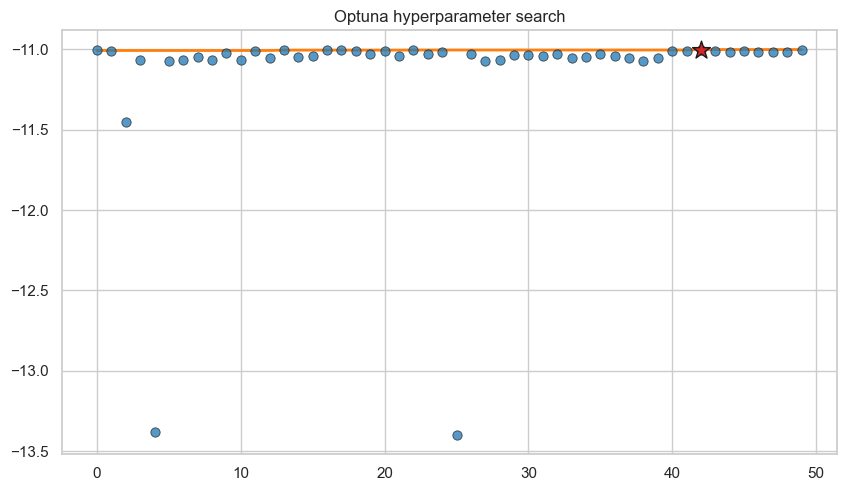

In [69]:
optuna_hist = pd.read_csv("../optuna_optimization_history.csv")
optuna_hist.sort_values(by="best_value")
fig, ax = plt.subplots(figsize=(10, 5.5))

# Plotear todos los trials individuales (puntos azules)
ax.scatter(
    optuna_hist["trial_number"],
    optuna_hist["value"],
    color="#1f77b4",
    alpha=0.75,
    edgecolors="k",
    linewidths=0.6,
    s=45,
    label="Objective Value",
    zorder=3,
)

# Plotear la línea del progreso del mejor valor (línea naranja)
ax.plot(
    optuna_hist["trial_number"],
    optuna_hist["best_value"],
    color="#ff7f0e",
    linestyle="-",
    linewidth=2,
    label="Best Value",
    zorder=2,
)

# Encontrar y destacar el mejor trial con una estrella roja grande
best_idx = optuna_hist["value"].idxmax()
best_trial = optuna_hist.loc[best_idx]
ax.scatter(
    best_trial["trial_number"],
    best_trial["value"],
    color="#d62728",
    s=180,
    marker="*",
    edgecolors="k",
    label=f"Best Trial (Trial {int(best_trial['trial_number'])})",
    zorder=4,
)
ax.set_title("Optuna hyperparameter search")

In [90]:
cols_codons=[]
for a in ["A","C","T","G"]:
    for b in ["A","C","T","G"]:
        for c in ["A","C","T","G"]:
            cols_codons.append(f"codon_{a}{b}{c}")
cols_est = cols_estaticas
cols_est.extend(cols_codons)
print(cols_est)

['associated_gene', 'associated_transcript', 'ref_length', 'ref_exons', 'strand', 'counts_transcript', 'TS', 'RIN', 'seqbatch', 'time', 'dip_test_TSS', 'dip_test_TSS_pval', 'exon_junction_density', 'porc_GC', 'CPM_transcript', 'length_CDS', 'porc_GC_CDS', 'length_3pUTR', 'porc_GC_3pUTR', 'length_5pUTR', 'porc_GC_5pUTR', 'RIN_TS', 'n_combs', 'codon_AAA', 'codon_AAC', 'codon_AAT', 'codon_AAG', 'codon_ACA', 'codon_ACC', 'codon_ACT', 'codon_ACG', 'codon_ATA', 'codon_ATC', 'codon_ATT', 'codon_ATG', 'codon_AGA', 'codon_AGC', 'codon_AGT', 'codon_AGG', 'codon_CAA', 'codon_CAC', 'codon_CAT', 'codon_CAG', 'codon_CCA', 'codon_CCC', 'codon_CCT', 'codon_CCG', 'codon_CTA', 'codon_CTC', 'codon_CTT', 'codon_CTG', 'codon_CGA', 'codon_CGC', 'codon_CGT', 'codon_CGG', 'codon_TAA', 'codon_TAC', 'codon_TAT', 'codon_TAG', 'codon_TCA', 'codon_TCC', 'codon_TCT', 'codon_TCG', 'codon_TTA', 'codon_TTC', 'codon_TTT', 'codon_TTG', 'codon_TGA', 'codon_TGC', 'codon_TGT', 'codon_TGG', 'codon_GAA', 'codon_GAC', 'codon_

length                         0
structural_category            0
associated_gene                0
associated_transcript          0
ref_length                     0
ref_exons                      0
diff_to_gene_TSS               0
diff_to_gene_TTS               0
strand                         0
covered_exons                  0
counts_transcript              0
dip_test_TSS                   0
dip_test_TSS_pval              0
counts                         0
CV_diff_to_gene_TSS            0
CV_diff_to_gene_TTS            0
TS                             0
RIN                            0
seqbatch                       0
time                           0
exon_junction_density          0
porc_GC                        0
CPM                            0
CPM_transcript                 0
clave                          0
ratio_counts                   0
delta(diff_to_gene_TSS)        0
Cov_D1                         0
Cov_D2                         0
Cov_D3                         0
Cov_D4    